# Optimization Comparison

Compares `profile_pipeline.py` benchmark CSVs against each other to see
whether an optimization step improved or regressed performance - latency,
communication overhead, and peak memory, at each sequence length.

## Adding a new run

Run `python scripts/profile_pipeline.py --output benchmarks/<name>.csv`
after each change, then add one line to the `RUNS` dict below:

```python
RUNS = {
    "baseline": "../benchmarks/pipeline_baseline.csv",
    "persist sockets": "../benchmarks/opt1_persist_sockets.csv",
}
```

The key is whatever label you want in the charts and tables. The **first
entry is treated as the baseline** everything else is compared against.
Re-run all cells after editing `RUNS` - nothing else needs to change.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Fixed categorical order - never auto-cycled, so a given run keeps the
# same color across every chart regardless of what else is in RUNS.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

# Diverging blue<->red for the improvement/regression table below - not
# the red/green stoplight pair, which is the classic red-green
# colorblind confusion.
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "improve_regress", ["#2a78d6", "#f0efec", "#e34948"]
)

## Runs to Compare

In [7]:
# Edit this dict to add/remove runs. Order matters - it's also the
# color and legend order everywhere below. The first entry is treated
# as the baseline for the improvement/regression comparison.
RUNS = {
    # "single node": "../benchmarks/single_node_baseline_pi.csv",
    "baseline": "../benchmarks/rpi/pipeline_baseline.csv",
    "State cache": "../benchmarks/rpi/opt1_add_state_cache.csv",
}

In [8]:
def load_runs(runs: dict[str, str]) -> pd.DataFrame:
    """
    Load and concatenate each run's CSV, tagging rows with the run name.
    """
    frames = []
    for name, path in runs.items():
        frame = pd.read_csv(path)
        frame["run"] = name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


df = load_runs(RUNS)
run_names = list(RUNS.keys())
run_colors = dict(zip(run_names, CATEGORICAL_PALETTE))
baseline_name = run_names[0]

df[
    [
        "run",
        "pass_type",
        "tokens",
        "mean_ms",
        "communication_overhead_ms",
        "peak_memory_mb",
    ]
]

,run,pass_type,tokens,mean_ms,communication_overhead_ms,peak_memory_mb
0,baseline,forward_pass,64,934.25,152.28,1276
1,baseline,generate_30,64,31522.25,5596.40,1294
2,baseline,forward_pass,128,1551.32,299.47,1315
3,baseline,generate_30,128,51007.86,9831.40,1370
4,baseline,forward_pass,512,5893.08,1179.28,1269
5,baseline,generate_30,512,178377.47,36505.10,1276
6,baseline,forward_pass,1024,12696.99,2364.31,1050
7,baseline,generate_30,1024,357960.85,71540.41,1052
8,State cache,forward_pass,64,918.62,151.34,1092
9,State cache,generate_30,64,10301.23,444.86,1093


## Latency vs Sequence Length

One panel per `pass_type`, one line per run. The shaded band is that run's
min-max range across its timed runs at that sequence length.

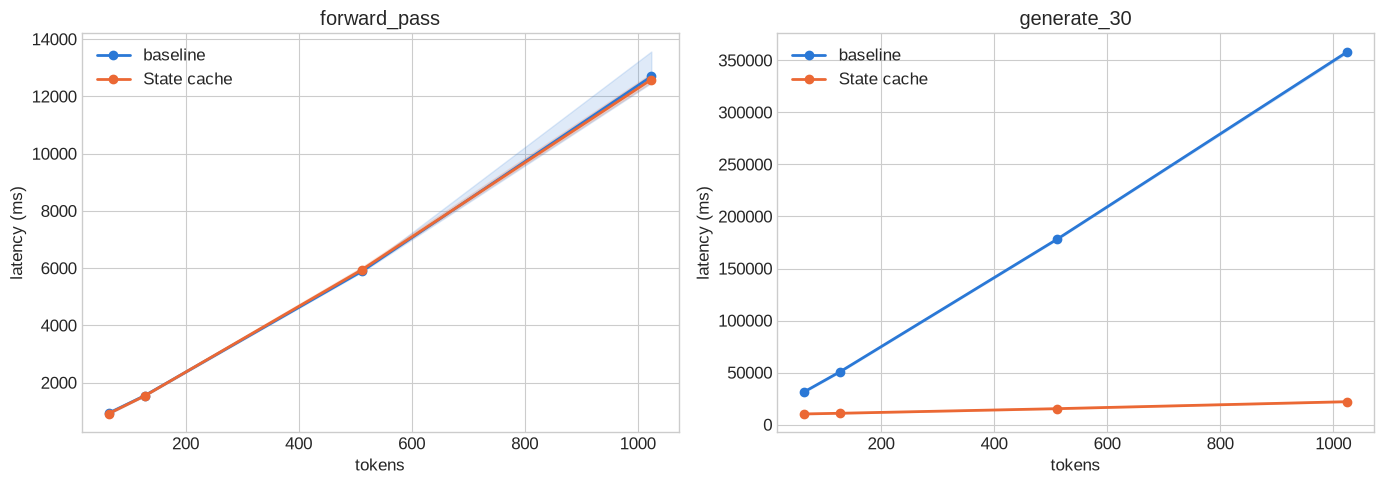

In [9]:
pass_types = sorted(df["pass_type"].unique())
fig, axes = plt.subplots(
    1, len(pass_types), figsize=(7 * len(pass_types), 5), squeeze=False
)
axes = axes[0]

for ax, pass_type in zip(axes, pass_types):
    sub = df[df["pass_type"] == pass_type]
    for run in run_names:
        g = sub[sub["run"] == run].sort_values("tokens")
        if g.empty:
            continue
        ax.plot(
            g["tokens"],
            g["mean_ms"],
            marker="o",
            linewidth=2,
            color=run_colors[run],
            label=run,
        )
        ax.fill_between(
            g["tokens"], g["min_ms"], g["max_ms"], alpha=0.15, color=run_colors[run]
        )
    ax.set_title(pass_type)
    ax.set_xlabel("tokens")
    ax.set_ylabel("latency (ms)")
    ax.legend()

plt.tight_layout()
plt.show()

## Improvement / Degradation Summary

The direct numeric answer: % change in `mean_ms` vs the baseline run, for
every (pass_type, tokens) combination. **Negative (blue) = faster,
positive (red) = slower.**

In [10]:
pivot = df.pivot_table(index=["pass_type", "tokens"], columns="run", values="mean_ms")
pivot = pivot[run_names]  # keep declared order, not alphabetical

pct_change = pivot.copy()
for run in run_names:
    if run == baseline_name:
        pct_change[run] = 0.0
    else:
        pct_change[run] = (
            (pivot[run] - pivot[baseline_name]) / pivot[baseline_name] * 100
        )

non_baseline = pct_change.drop(columns=[baseline_name])
max_abs = non_baseline.abs().max().max() if not non_baseline.empty else 1.0
max_abs = max_abs or 1.0

(
    pct_change.style.background_gradient(
        cmap=DIVERGING_CMAP, vmin=-max_abs, vmax=max_abs, axis=None
    )
    .format("{:+.1f}%")
    .set_caption(
        f"% change in mean_ms vs '{baseline_name}' (negative = faster, positive = slower)"
    )
)

## Communication Overhead by Run

`forward_pass` only - one pipeline round trip, so this isolates
per-hop network/connection cost without generation's 30x multiplier
muddying the comparison.

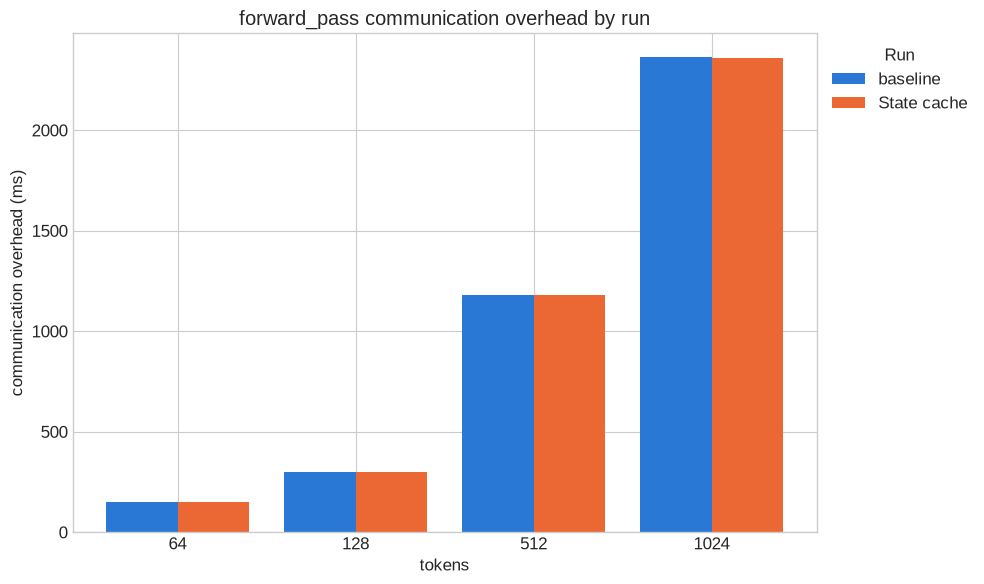

In [11]:
fp = df[df["pass_type"] == "forward_pass"]
tokens_list = sorted(fp["tokens"].unique())
x = np.arange(len(tokens_list))
width = 0.8 / len(run_names)

fig, ax = plt.subplots()
for i, run in enumerate(run_names):
    g = fp[fp["run"] == run].set_index("tokens").reindex(tokens_list)
    ax.bar(
        x + i * width,
        g["communication_overhead_ms"],
        width,
        label=run,
        color=run_colors[run],
    )

ax.set_xticks(x + width * (len(run_names) - 1) / 2)
ax.set_xticklabels(tokens_list)
ax.set_xlabel("tokens")
ax.set_ylabel("communication overhead (ms)")
ax.set_title("forward_pass communication overhead by run")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Run")
plt.tight_layout()
plt.show()

## Peak Memory by Run

`forward_pass` only, since generate's peak is the same model resident in
memory - just held longer, not larger.

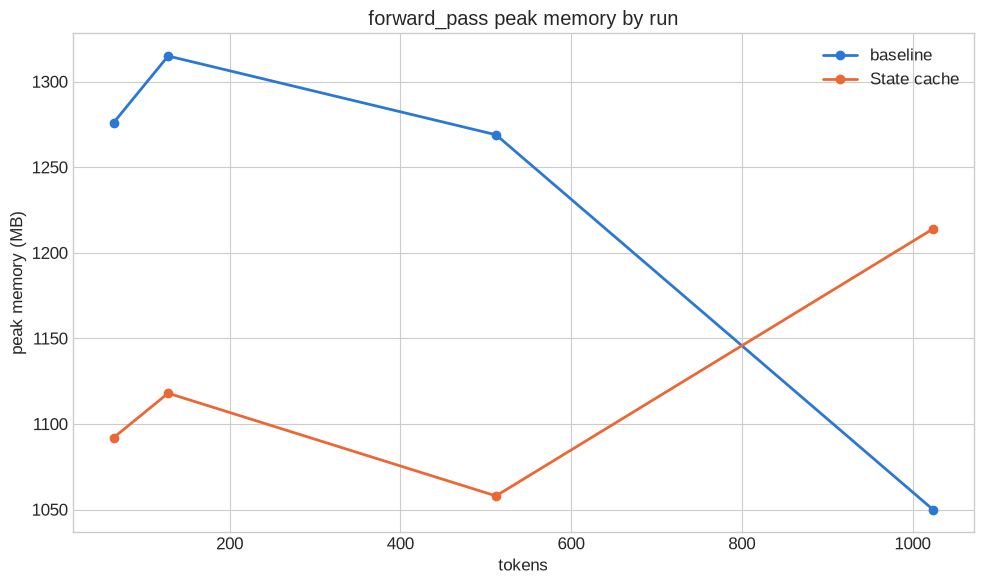

In [12]:
fig, ax = plt.subplots()
for run in run_names:
    g = fp[fp["run"] == run].sort_values("tokens")
    ax.plot(
        g["tokens"],
        g["peak_memory_mb"],
        marker="o",
        linewidth=2,
        color=run_colors[run],
        label=run,
    )

ax.set_xlabel("tokens")
ax.set_ylabel("peak memory (MB)")
ax.set_title("forward_pass peak memory by run")
ax.legend()
plt.tight_layout()
plt.show()